### Importación de datos



In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [10]:
import pandas as pd
pd.reset_option('display.float_format')

In [13]:
df_global = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

print("--- Estructura General del Dataset ---")
df_global.info()

print("\n--- Conteo de Valores Nulos ---")
print(df_global.isnull().sum())

print("\n--- Primeros registros ---")
display(df_global.head())

--- Estructura General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                9435 non-null   object 
 1   Categoría del Producto  9435 non-null   object 
 2   Precio                  9435 non-null   float64
 3   Costo de envío          9435 non-null   float64
 4   Fecha de Compra         9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Lugar de Compra         9435 non-null   object 
 7   Calificación            9435 non-null   int64  
 8   Método de pago          9435 non-null   object 
 9   Cantidad de cuotas      9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 884.7+ KB

--- Conteo de Valores Nulos ---
Producto       

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


# 2. Ventas por categoría

In [20]:
resumen_facturacion = pd.DataFrame({
    'Tienda': ['Tienda A', 'Tienda B', 'Tienda C', 'Tienda D'],
    'Facturación Total': [tienda['Precio'].sum(), tienda2['Precio'].sum(),
                          tienda3['Precio'].sum(), tienda4['Precio'].sum()]
}).sort_values(by='Facturación Total', ascending=False)

print("REPORTE DE FACTURACIÓN TOTAL")
display(resumen_facturacion.style.format({'Facturación Total': '${:,.0f}'}))



REPORTE DE FACTURACIÓN TOTAL


,Tienda,Facturación Total
0,Tienda A,"$1,150,880,400"
1,Tienda B,"$1,116,343,500"
2,Tienda C,"$1,098,019,600"
3,Tienda D,"$1,038,375,700"


# 3. Calificación promedio de la tienda


In [21]:
nombres_tiendas = ["Tienda A", "Tienda B", "Tienda C", "Tienda D"]
datasets = [tienda, tienda2, tienda3, tienda4]

print("VENTAS POR CATEGORÍA (Top 3 por tienda):")
print("-" * 40)


for i in range(len(datasets)):
    print(f"\n📍 {nombres_tiendas[i]}:")
    # value_counts() cuenta cuántos productos hay por cada categoría
    top_categorias = datasets[i]['Categoría del Producto'].value_counts().head(3)

    # Lo mostramos de forma limpia
    for cat, total in top_categorias.items():
        print(f"- {cat}: {total} unidades")



VENTAS POR CATEGORÍA (Top 3 por tienda):
----------------------------------------

📍 Tienda A:
- Muebles: 465 unidades
- Electrónicos: 448 unidades
- Juguetes: 324 unidades

📍 Tienda B:
- Muebles: 442 unidades
- Electrónicos: 422 unidades
- Juguetes: 313 unidades

📍 Tienda C:
- Muebles: 499 unidades
- Electrónicos: 451 unidades
- Juguetes: 315 unidades

📍 Tienda D:
- Muebles: 480 unidades
- Electrónicos: 451 unidades
- Juguetes: 338 unidades


In [ ]:
calificaciones_promedio = pd.DataFrame({
    'Tienda': ['Tienda A', 'Tienda B', 'Tienda C', 'Tienda D'],
    'Satisfacción': [tienda['Calificación'].mean(), tienda2['Calificación'].mean(),
                     tienda3['Calificación'].mean(), tienda4['Calificación'].mean()]
})

df_final = resumen_facturacion.merge(resumen_envio, on='Tienda')
df_final = df_final.merge(calificaciones_promedio, on='Tienda')

df_final = df_final.rename(columns={
    'Facturación Total': 'Facturación',
    'Envío Promedio': 'Costo Envío'
})

print("DataFrame df_final creado:")
display(df_final)

# 4. Productos más y menos vendidos

In [18]:
def analizar_productos(df_tienda, nombre_tienda):
    conteo_productos = df_tienda['Producto'].value_counts()

    mas_vendidos = conteo_productos.head(3)
    menos_vendidos = conteo_productos.tail(3)

    print(f"--- ANÁLISIS DE PRODUCTOS: {nombre_tienda} ---")
    print("Más vendidos :)")
    for prod, cant in mas_vendidos.items():
        print(f"   - {prod}: {cant} unidades")

    print("Menos vendidos :(")
    for prod, cant in menos_vendidos.items():
        print(f"   - {prod}: {cant} unidades")
    print("-" * 40)

analizar_productos(tienda, "Tienda A")
analizar_productos(tienda2, "Tienda B")
analizar_productos(tienda3, "Tienda C")
analizar_productos(tienda4, "Tienda D")

--- ANÁLISIS DE PRODUCTOS: Tienda A ---
Más vendidos :)
   - Microondas: 60 unidades
   - TV LED UHD 4K: 60 unidades
   - Armario: 60 unidades
Menos vendidos :(
   - Olla de presión: 35 unidades
   - Auriculares con micrófono: 33 unidades
   - Celular ABXY: 33 unidades
----------------------------------------
--- ANÁLISIS DE PRODUCTOS: Tienda B ---
Más vendidos :)
   - Iniciando en programación: 65 unidades
   - Microondas: 62 unidades
   - Batería: 61 unidades
Menos vendidos :(
   - Mesa de comedor: 34 unidades
   - Impresora: 34 unidades
   - Juego de mesa: 32 unidades
----------------------------------------
--- ANÁLISIS DE PRODUCTOS: Tienda C ---
Más vendidos :)
   - Kit de bancas: 57 unidades
   - Mesa de comedor: 56 unidades
   - Cama king: 56 unidades
Menos vendidos :(
   - Mochila: 36 unidades
   - Microondas: 36 unidades
   - Bloques de construcción: 35 unidades
----------------------------------------
--- ANÁLISIS DE PRODUCTOS: Tienda D ---
Más vendidos :)
   - Cama box: 62 u

# 5. Envío promedio por tienda

In [23]:
resumen_envio = pd.DataFrame({
    'Tienda': ['Tienda A', 'Tienda B', 'Tienda C', 'Tienda D'],
    'Envío Promedio': [tienda['Costo de envío'].mean(), tienda2['Costo de envío'].mean(),
                       tienda3['Costo de envío'].mean(), tienda4['Costo de envío'].mean()]
}).sort_values(by='Envío Promedio', ascending=True)

print("Envío promedio")
display(resumen_envio.style.format({'Envío Promedio': '${:,.2f}'}))

Envío promedio


,Tienda,Envío Promedio
3,Tienda D,"$23,459.46"
2,Tienda C,"$24,805.68"
1,Tienda B,"$25,216.24"
0,Tienda A,"$26,018.61"


# 6. Visualización


In [27]:
df_final = pd.DataFrame({
    'Tienda': ['Tienda A', 'Tienda B', 'Tienda C', 'Tienda D'],
    'Facturación': [tienda['Precio'].sum(), tienda2['Precio'].sum(),
                     tienda3['Precio'].sum(), tienda4['Precio'].sum()],
    'Satisfacción': [tienda['Calificación'].mean(), tienda2['Calificación'].mean(),
                     tienda3['Calificación'].mean(), tienda4['Calificación'].mean()],
    'Costo Envío': [tienda['Costo de envío'].mean(), tienda2['Costo de envío'].mean(),
                    tienda3['Costo de envío'].mean(), tienda4['Costo de envío'].mean()]
})

print("Toma de decisiones")
display(df_final.style.format({
    'Facturación': '${:,.0f}',
    'Satisfacción': '{:.2f} ',
    'Costo Envío': '${:,.2f}'
}).highlight_min(subset=['Facturación'], color='#ff9999') # Resalta en rojo la tienda que menos vende
  .highlight_max(subset=['Satisfacción'], color='#99ff99')) # Resalta en verde la mejor calificada



Toma de decisiones


,Tienda,Facturación,Satisfacción,Costo Envío
0,Tienda A,"$1,150,880,400",3.98,"$26,018.61"
1,Tienda B,"$1,116,343,500",4.04,"$25,216.24"
2,Tienda C,"$1,098,019,600",4.05,"$24,805.68"
3,Tienda D,"$1,038,375,700",4.00,"$23,459.46"


/tmp/ipykernel_381/148356633.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Tienda', y='Facturación', data=df_final, palette='viridis')
/tmp/ipykernel_381/148356633.py:20: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(ax=axes[1], x='Tienda', y='Satisfacción', data=df_final, color='#2c3e50', scale=1.5)


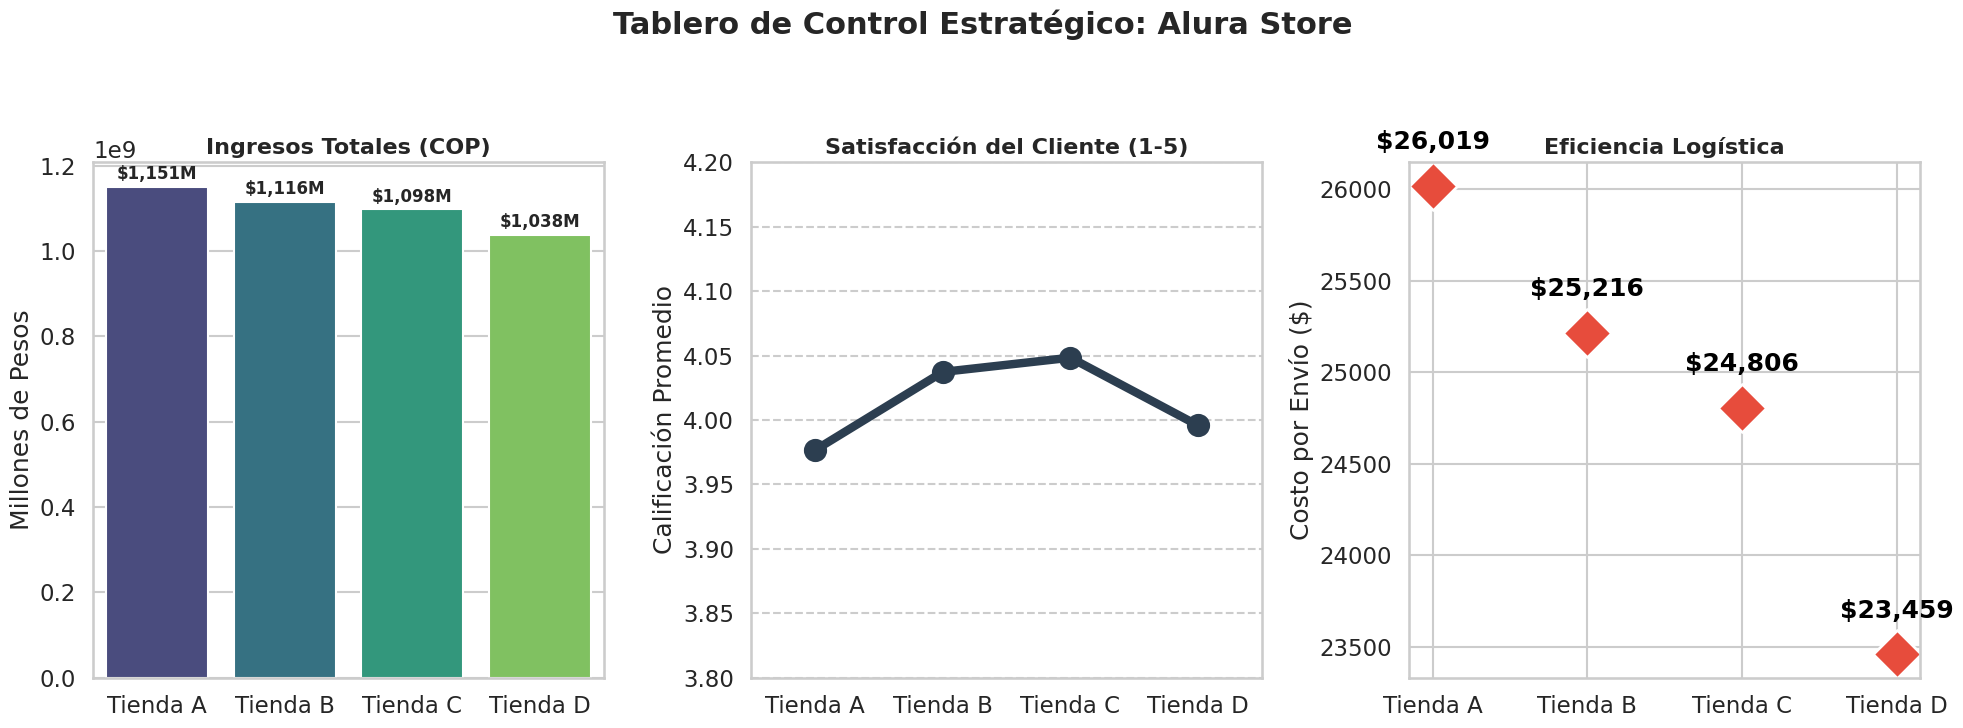

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Tablero de Control Estratégico: Alura Store', fontsize=22, fontweight='bold', y=1.05)

sns.barplot(ax=axes[0], x='Tienda', y='Facturación', data=df_final, palette='viridis')
axes[0].set_title('Ingresos Totales (COP)', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Millones de Pesos')
axes[0].set_xlabel('')
for p in axes[0].patches:
    axes[0].annotate(f'${p.get_height()/1e6:,.0f}M',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points',
                     fontsize=12, fontweight='bold')

sns.pointplot(ax=axes[1], x='Tienda', y='Satisfacción', data=df_final, color='#2c3e50', scale=1.5)
axes[1].set_title('Satisfacción del Cliente (1-5)', fontsize=16, fontweight='bold')
axes[1].set_ylim(3.8, 4.2)
axes[1].set_ylabel('Calificación Promedio')
axes[1].set_xlabel('')
axes[1].grid(True, axis='y', linestyle='--')

sns.scatterplot(ax=axes[2], x='Tienda', y='Costo Envío', data=df_final, s=600, color='#e74c3c', marker='D')
axes[2].set_title('Eficiencia Logística', fontsize=16, fontweight='bold')
axes[2].set_ylabel('Costo por Envío ($)')
axes[2].set_xlabel('')
for i in range(df_final.shape[0]):
    axes[2].text(x=i, y=df_final['Costo Envío'].iloc[i]+200,
                 s=f"${df_final['Costo Envío'].iloc[i]:,.0f}",
                 horizontalalignment='center', size='medium', color='black', weight='semibold')

plt.tight_layout()
plt.show()

# Informe final


**Introducción**

El informe presenta una recomendación basada en el análisis de facturación, satisfacción del cliente, logística y volumen de ventas de las sucursales de Alura Store, con el objetivo de apoyar la decisión del Sr. Juan y preservar la estabilidad financiera de la empresa.

**Principales hallazgos**

El análisis muestra diferencias claras entre las tiendas. La Tienda A lidera en facturación con más de $1.150 millones, mientras que la Tienda D registra el menor nivel de ingresos. En términos de reputación, la Tienda C posee la mejor calificación de clientes (4,05 ⭐). Los costos de envío son similares en todas las sucursales, por lo que la Tienda D no presenta ventajas logísticas que compensen su bajo desempeño. Además, es la tienda con menor volumen de ventas en categorías clave como muebles y electrónica.

**Conclusión**

Se recomienda vender la Tienda D, ya que presenta el rendimiento más bajo sin ventajas competitivas claras. Esta decisión permitiría liberar capital manteniendo las sucursales más fuertes: la Tienda A (mayor facturación) y la Tienda C (mejor valoración de clientes).